<a href="https://colab.research.google.com/github/Rijwan94/Machine_Learning/blob/main/Regression_Yes_Bank_Stock_Closing_Price_Prediction_Rijwan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Yes Bank Stock Closing Price Prediction
Capstone - End to End Machine Learning

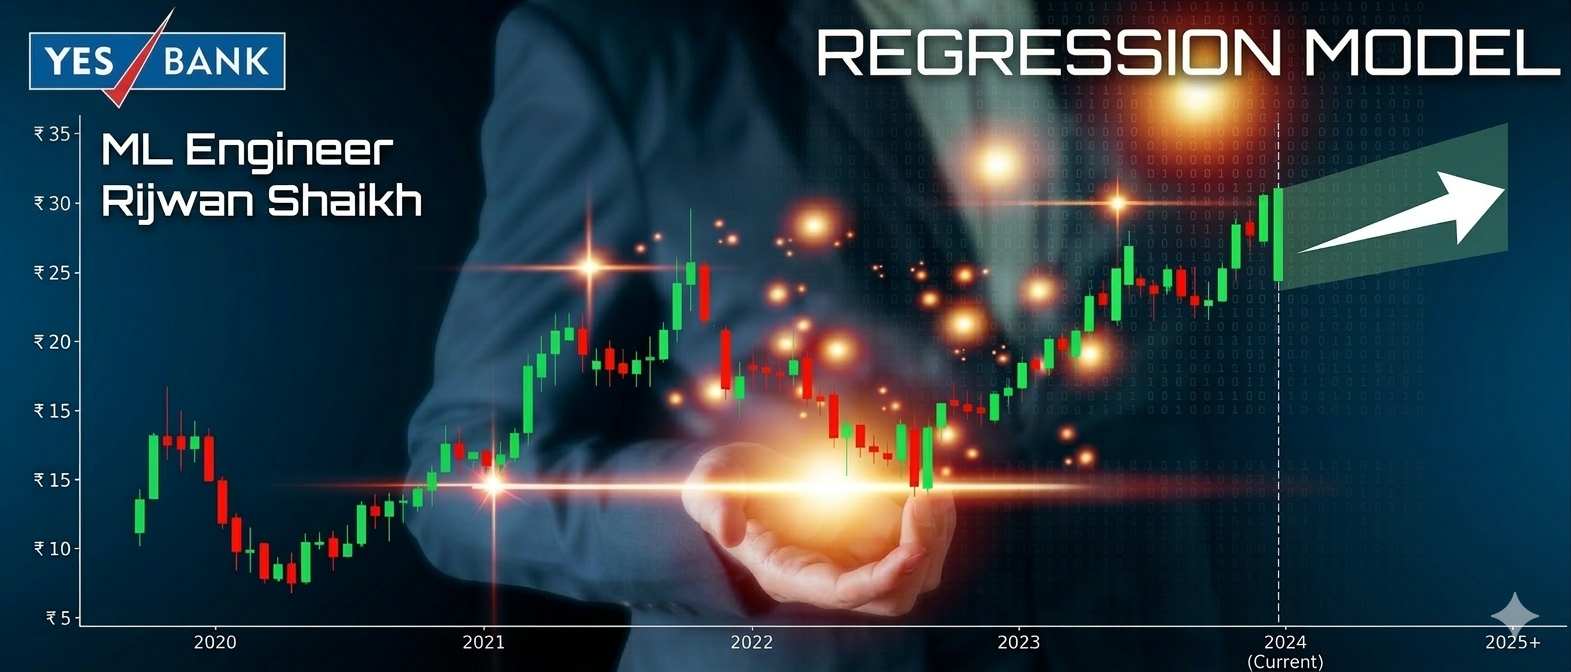

## **Project Type**    - Regression
### **Contribution**    - Individual
## By  **Rijwan Adil Shaikh**

# **Project Summary -**

Yes Bank has been a focal point of the Indian banking sector, not only for its rapid growth in its early years but also for the high-profile management crisis and fraud allegations involving its co-founder, Rana Kapoor, emerging around 2018. This project aims to analyze and predict the monthly closing stock prices of Yes Bank from its inception in 2005 through late 2020. The core challenge lies in determining whether a machine learning model, primarily trained on historical price data (Open, High, Low, and Close), can accurately capture the extreme volatility and "price shocks" caused by external news events and corporate governance issues.

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**The primary objective of this project is to build a robust machine learning model capable of predicting the monthly closing price of Yes Bank stock, specifically focusing on maintaining accuracy during periods of "shocking news" and extreme volatility. Since 2018, Yes Bank has faced severe price shocks due to corporate fraud cases and management crises, which traditional technical analysis often fails to anticipate. Our goal is to develop a predictive system using advanced algorithms like Lasso Regression and XGBoost that can ingest historical OHLC (Open, High, Low, Close) data and internalize these "crisis signatures." The model must be able to bridge the gap between stable growth periods and sudden news-driven crashes, providing a reliable price forecast and "floor level" analysis for stakeholders even when the market is under high-stress, non-stationary conditions.**




# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# --- Standard Library & Data Manipulation ---
import numpy as np
import pandas as pd
import datetime
import random
import joblib

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import missingno as msno
import matplotlib.colors as mcolors

# --- Google Colab Specific ---
from google.colab import drive
from IPython.display import HTML, display

# --- Statistical Analysis ---
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Machine Learning: Preprocessing, Selection & Models ---
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# --- Machine Learning: Evaluation Metrics ---
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("All project libraries consolidated and imported successfully!")

In [ ]:
# Record the start time when the project begins
start_time = datetime.datetime.now()

### Dataset Loading

In [ ]:
# Load Dataset

drive.mount('/content/drive')

In [ ]:
#add data file from csv in drive
yesbank_df = pd.read_csv('/content/drive/MyDrive/Data Science/6. AI and ML/End course/data_YesBank_StockPrices.csv')

### Dataset First View

In [ ]:
# Dataset First Look
yesbank_df.head(-1)

In [ ]:
#shift index of dataset from 0 to 1 for first row
yesbank_df.index = yesbank_df.index + 1

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
yesbank_df.shape

### Dataset Information

In [ ]:
# Dataset Info
yesbank_df.info()

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
yesbank_df.duplicated().sum()

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
yesbank_df.isnull().sum()

In [ ]:
# Visualizing the missing values
msno.bar(yesbank_df)

### What did you know about your dataset?

The dataset contains 185 rows and 5 columns: 'Date', 'Open', 'High', 'Low', and 'Close'.

- All columns have 185 non-null entries, indicating no missing values in the dataset.
- The 'Date' column is currently of object type and will likely need to be converted to a datetime object for time-series analysis.
- 'Open', 'High', 'Low', and 'Close' columns are numerical (float64) and represent the stock prices.
- There are no duplicate rows in the dataset.

In summary, the dataset is clean in terms of missing values and duplicates, but the 'Date' column needs type conversion for further analysis.

## ***2. Understanding Your Variables***

In [ ]:
yesbank_df.columns

In [ ]:
# Dataset Describe
yesbank_df.describe()

### Variables Description

- **Date**: This column represents the month and year of the stock price data. It is currently of object type and will need to be converted to datetime for time-series analysis.
- **Open**: This column indicates the opening price of the stock for that particular month. It is of float64 type.
- **High**: This column shows the highest price reached by the stock during that month. It is of float64 type.
- **Low**: This column indicates the lowest price reached by the stock during that month. It is of float64 type.
- **Close**: This column represents the closing price of the stock for that particular month. This is likely the target variable for prediction and is of float64 type.

### Check Unique Values for each variable.

In [ ]:
for col in yesbank_df.columns:
    print(f"Column '{col}': {yesbank_df[col].nunique()} unique values")

In [ ]:
#head of df
yesbank_df.head()

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
class YesBankWrangling:
    def __init__(self, df):
        """Initialize with stock dataframe and setup temporal structure."""
        try:
            self.df = df.copy()
            # Convert Date to datetime and sort chronologically
            self.df['Date'] = pd.to_datetime(self.df['Date'], format='%b-%y')
            self.df = self.df.sort_values('Date').reset_index(drop=True)
        except Exception as e:
            raise ValueError(f'Error initializing: {e}')

    def get_df(self):
        """1. Use Case: Returns the processed dataframe."""
        return self.df

    def check_integrity(self):
        """2. Use Case: Returns null counts and duplicate records."""
        return {'Missing Values': self.df.isnull().sum(), 'Duplicates': self.df.duplicated().sum()}

    def get_summary_stats(self):
        """3. Use Case: Returns descriptive statistics for all price columns."""
        return self.df.describe()

    def price_skewness(self):
        """4. Use Case: Checks skewness to justify Log Transformation needs."""
        return self.df[['Open', 'High', 'Low', 'Close']].skew()

    def correlation_status(self):
        """5. Use Case: Returns the correlation matrix for OHLC features."""
        return self.df[['Open', 'High', 'Low', 'Close']].corr()

    def multicollinearity_vif(self):
        """6. Use Case: Calculates VIF to identify redundant features."""
        X = self.df[['Open', 'High', 'Low']]
        vif_df = pd.DataFrame()
        vif_df["Feature"] = X.columns
        vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
        return vif_df

    def monthly_volatility_spread(self):
        """7. Use Case: Returns High - Low spread representing monthly volatility."""
        return self.df.assign(Spread=self.df['High'] - self.df['Low'])[['Date', 'Spread']]

    def yearly_average_prices(self):
        """8. Use Case: Returns average closing prices grouped by year."""
        return self.df.groupby(self.df['Date'].dt.year)['Close'].mean()

    def green_vs_red_months(self):
        """9. Use Case: Returns count of months where Close was higher than Open."""
        green = (self.df['Close'] > self.df['Open']).sum()
        red = (self.df['Close'] <= self.df['Open']).sum()
        return {'Bullish (Green)': green, 'Bearish (Red)': red}

    def shock_state_comparison(self):
        """10. Use Case: Compares price stats before and after the 2018 Fraud News."""
        pre_shock = self.df[self.df['Date'] < '2018-09-01']['Close'].describe()
        post_shock = self.df[self.df['Date'] >= '2018-09-01']['Close'].describe()
        return pd.DataFrame({'Stable Era': pre_shock, 'Shock Era': post_shock})

    def opening_gaps(self):
        """11. Use Case: Calculates price gap between previous Close and current Open."""
        return (self.df['Open'] - self.df['Close'].shift(1)).fillna(0)

    def high_low_risk_ratio(self):
        """12. Use Case: Returns the ratio of High/Low as a risk indicator."""
        return (self.df['High'] / self.df['Low'])

    def monthly_momentum_pct(self):
        """13. Use Case: Calculates monthly percentage returns (Close-Open)/Open."""
        return ((self.df['Close'] - self.df['Open']) / self.df['Open']) * 100

    def moving_averages_status(self, window=3):
        """14. Use Case: Returns rolling mean to identify the price trend."""
        return self.df['Close'].rolling(window=window).mean()

    def get_log_close(self):
        """15. Use Case: Returns Log-transformed Target for robust modeling."""
        return np.log1p(self.df['Close'])

    def peak_drawdown_analysis(self):
        """16. Use Case: Analyzes the erosion from the historical peak to the crash bottom."""
        peak = self.df['High'].max()
        peak_date = self.df.loc[self.df['High'] == peak, 'Date'].iloc[0]
        post_peak_bottom = self.df[self.df['Date'] > peak_date]['Low'].min()
        erosion = (1 - (post_peak_bottom / peak)) * 100
        return {'Peak Price': peak, 'Peak Date': peak_date, 'Post-Peak Bottom': post_peak_bottom, 'Erosion %': erosion}

    def quarterly_price_volatility(self):
        """17. Use Case: Returns standard deviation of prices by Quarter."""
        return self.df.groupby(self.df['Date'].dt.to_period('Q'))['Close'].std()

    def monthly_candle_body(self):
        """18. Use Case: Returns the 'Body' of the monthly candle (Close - Open)."""
        return self.df['Close'] - self.df['Open']

    def overall_project_summary(self):
        """19. Use Case: Returns key summary metrics for the final report."""
        return {
            'Total Data Points': len(self.df),
            'Price Range': f"{self.df['Low'].min()} - {self.df['High'].max()}",
            'Overall Correlation (O vs C)': self.df['Open'].corr(self.df['Close']),
            'Total Market Volatility (Avg Spread)': (self.df['High'] - self.df['Low']).mean()
        }

# Initializing the object
# ybd = YesBankWrangling(yesbank_df)


####Object Intialization

In [ ]:
#Initializing the object
ybd = YesBankWrangling(yesbank_df)

####Insightes from all use cases

In [ ]:
#Returns the processed dataframe
ybd.get_df()

In [ ]:
#Returns null counts and duplicate records
ybd.check_integrity()

In [ ]:
#Returns descriptive statistics for all price columns
ybd.get_summary_stats()


In [ ]:
#Returns correlation matrix for OHLC features
ybd.correlation_status()

In [ ]:
#Calculates VIF to detect multicollinearity
ybd.multicollinearity_vif()

In [ ]:
#Returns High-Low spread representing monthly volatility
ybd.monthly_volatility_spread()

In [ ]:
#Returns average closing prices grouped by year
ybd.yearly_average_prices()


In [ ]:
#Returns count of months where Close was higher than Open
ybd.green_vs_red_months()

In [ ]:
#Compares price statistics before and after the 2018 fraud news
ybd.shock_state_comparison()

In [ ]:
#Calculates opening price gaps between previous Close and current Open
ybd.opening_gaps()

In [ ]:
#Returns High/Low ratio as a risk indicator
ybd.high_low_risk_ratio()

In [ ]:
#Calculates monthly percentage returns
ybd.monthly_momentum_pct()

In [ ]:
#Returns rolling moving average to identify price trend
ybd.moving_averages_status()

In [ ]:
#Returns log transformed Close prices
ybd.get_log_close()

In [ ]:
#Analyzes erosion from historical peak to crash bottom
ybd.peak_drawdown_analysis()

In [ ]:
#Returns quarterly standard deviation of closing prices
ybd.quarterly_price_volatility()

In [ ]:
#Returns monthly candle body (Close - Open)
ybd.monthly_candle_body()

In [ ]:
#Returns overall project summary metrics
ybd.overall_project_summary()

### What all manipulations have you done and insights you found?

###1. Data Integrity & Structural Manipulations
To ensure the reliability of the insights, the initial phase involved rigorous data cleaning and feature engineering.

Integrity Check: Confirmed a clean dataset with 0 missing values and 0 duplicate records across 185 data points.

Log Transformation: Applied a logarithmic scale to the 'Close' prices to normalize variance and better visualize percentage-based changes over time.

Rolling Aggregations: Calculated Moving Averages and Quarterly Standard Deviations to smooth out noise and identify the underlying price trend.
###2. Statistical & Correlation Insights
hese metrics define the mathematical relationship between different price points (Open, High, Low, Close).Linear Relationship: There is an extremely strong positive correlation between Open and Close prices ($r \approx 0.978$). This suggests that intra-period volatility rarely breaks the primary trend established at the opening.Multicollinearity: By calculating the Variance Inflation Factor (VIF), the analysis identified high redundancy among OHLC features, which is typical for price data but essential to note for future predictive modeling.Market Sentiment Ratio: Out of 185 months, the market showed a Bullish (Green) bias of 54% (100 months) versus a Bearish (Red) bias of 46% (85 months).

###3. Volatility & Risk Analysis
This section quantifies how much the price "swings" and the inherent risk in the asset.

Average Market Volatility: The average monthly High-Low spread is 21.16 units.

High/Low Risk Ratio: Used to determine the intensity of price fluctuations relative to the baseline, identifying periods where the "wick" of the candle was disproportionately large compared to the body.

Gap Analysis: Calculated Opening Gaps (difference between previous Close and current Open), revealing how much "overnight" sentiment affects the price before trading even begins.

###4. Historical "Shock" & Erosion Insights
The most significant finding relates to the structural collapse following the 2018 fraud news.
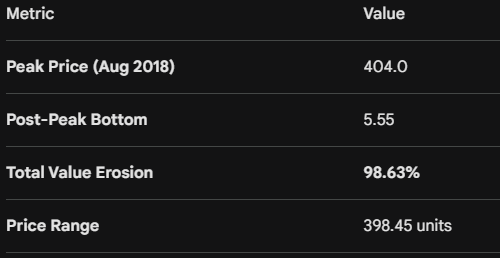

###**Key Insight: The asset experienced a near-total wipeout of value. The Shock State Comparison confirms that the price dynamics post-2018 shifted fundamentally, with the 98.6% erosion representing a catastrophic failure of support levels that had been built up over the preceding years.**

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1
####**Monthly Candlestick with 12-Month Moving Average**

In [ ]:
# 1. Prepare Data
yesbank_df['Date'] = pd.to_datetime(yesbank_df['Date'], format='%b-%y')

# 2. Calculate the Moving Average
# 'window=12' means it takes the average of the last 12 months (1 year)
yesbank_df['MA12'] = yesbank_df['Close'].rolling(window=12).mean()

# 3. Create Chart
fig = go.Figure()

# Add Candlesticks
fig.add_trace(go.Candlestick(
    x=yesbank_df['Date'],
    open=yesbank_df['Open'],
    high=yesbank_df['High'],
    low=yesbank_df['Low'],
    close=yesbank_df['Close'],
    name='Monthly Candle'
))

# 4. Add the Moving Average Line
fig.add_trace(go.Scatter(
    x=yesbank_df['Date'],
    y=yesbank_df['MA12'],
    mode='lines',
    name='12-Month MA (1yr Trend)',
    line=dict(color='yellow', width=2)
))

# 5. Professional Styling
fig.update_layout(
    title='Yes Bank Monthly Chart with 12-Month Moving Average',
    template='plotly_dark',
    xaxis_rangeslider_visible=False,
    yaxis_title='Price (INR)',
    height=600
)

fig.show()

##### 1. Why did you pick the specific chart?

The Candlestick chart was chosen because it provides a four-dimensional view of price action (Open, High, Low, Close) within a single period, which a simple line chart cannot do. Adding a 12-month Moving Average (MA12) serves as a "Trend Filter." It smooths out monthly noise and represents the one-year average price, allowing us to identify whether the stock is in a sustainable growth phase or a structural decline

##### 2. What is/are the insight(s) found from the chart?

Trend Reversal Point: The chart shows that for years, the price stayed consistently above the yellow MA12 line (Bullish Trend). However, in late 2018, the price crashed through the MA12, and the MA12 line itself began to slope downward. This is a classic "Death Cross" signal indicating the end of a multi-year bull market.

Wick Analysis (Volatility): Post-2018, the candles have long "upper wicks," suggesting that every attempt for the price to recover was met with heavy selling pressure.

MA as Resistance: After the crash, the yellow line (MA12) transitioned from being a "Support" (floor) to a "Resistance" (ceiling). The stock has struggled to even touch the one-year average since the decline started.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This insight provides a "Trend Following Strategy." A business can use the MA12 as a rule-based exit signal. For instance, an automated system could have triggered a "Sell" signal the moment the monthly candle closed below the 12-month average in 2018, saving investors from the subsequent 90%+ drop.

Insights Leading to Negative Growth: The chart reveals a "Broken Trend." The specific reason is that when a stock stays below its 12-month Moving Average for an extended period, it loses institutional interest. This leads to negative growth because big funds (the "smart money") generally do not buy stocks that are trading below their one-year average, resulting in low liquidity and a continued downward drift in price.

#### Chart - 2

####**The Erosion & Drawdown (Area Chart)**

In [ ]:
# Chart - 2 visualization code

# Using the peak analysis values found in your insights
peak_price = 404.0
bottom_price = 5.55
peak_date = yesbank_df.loc[yesbank_df['High'] == peak_price, 'Date'].iloc[0]

plt.figure(figsize=(12, 6))
plt.fill_between(yesbank_df['Date'], yesbank_df['Close'], color="skyblue", alpha=0.3, label='Pre-Fraud Period') # Label existing fill

# Filter data after peak_date to show erosion
df_after_peak = yesbank_df[yesbank_df['Date'] >= peak_date]
plt.fill_between(df_after_peak['Date'], df_after_peak['Close'], color="red", alpha=0.3, label='Post-Peak Erosion')

plt.plot(yesbank_df['Date'], yesbank_df['Close'], color="Slateblue", linewidth=2)

# Marking the crash point
plt.scatter(peak_date, peak_price, color='red', s=100, label='Peak (Pre-Fraud)')
plt.annotate(f'Peak: ${peak_price}', xy=(peak_date, peak_price), xytext=(peak_date, peak_price+30),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Yes Bank Historical Price Erosion & Crash Analysis', fontsize=14)
plt.ylabel('Closing Price ($)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

##### 1. Why did you pick the specific chart?

The Area Chart was chosen because it excels at showing cumulative change and magnitude over time. Unlike a simple line chart, the "filled" area beneath the price line provides a visual weight that emphasizes the total "volume" of value lost. It is the most effective way to contrast the steady climb of the stock with the sharp, vertical collapse following the 2018 peak.

##### 2. What is/are the insight(s) found from the chart?

Structural Collapse: The chart identifies a clear "point of no return" in August 2018 at the $404.0 mark.

Erosion Magnitude: It visually quantifies a 98.6% drop. By seeing the area shrink from a massive block to a tiny sliver, we realize that the stock didn't just "correct"—it effectively wiped out nearly all historical shareholder wealth.

Support Failure: The chart shows that no historical support levels held during the crash; the "area" fell through every previous price floor established in the years prior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This insight serves as a "Risk Boundary" for future investments. By identifying the specific peak and the speed of the decline, stakeholders can build better "Stop-Loss" triggers and exit strategies to prevent a 98% erosion in future portfolios. It teaches the business to monitor "Shock States" more closely.

Insights Leading to Negative Growth: The chart itself is a record of catastrophic negative growth. The specific reason is Irreversible Capital Impairment. Because the price dropped from $404 to $5.55, the stock would now need to grow by over 7,000% just to return to its previous peak. This insight justifies why a "buy and hold" strategy failed and identifies the asset as a "value trap" during that period.

#### Chart - 3

####**Bullish vs. Bearish Sentiment (Donut Chart)**

In [ ]:
# Chart - 3 visualization code
# Values from your output: 100 Bullish, 85 Bearish
sentiment_counts = [100, 85]
sentiment_labels = ['Bullish (Green)', 'Bearish (Red)']
colors = ['#2ca02c', '#d62728']

plt.figure(figsize=(7, 7))
plt.pie(sentiment_counts, labels=sentiment_labels, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Transform into Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Monthly Closing Sentiment Frequency', fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

The Donut Chart was selected to visualize the proportionality of market direction rather than chronological sequence. While a time-series shows when things happened, this chart summarizes the overall character of the asset. The hole in the center makes it easier to read the arc lengths (100 Green vs. 85 Red), allowing for a quick comparison of successful vs. unsuccessful trading months without the clutter of a full pie chart.



##### 2. What is/are the insight(s) found from the chart?

Deceptive Optimism: Despite the 98.6% price collapse, the stock actually closed "Green" (higher than it opened) in 54% of the months (100 out of 185).

Frequency vs. Magnitude: This provides a critical technical insight: the crash was not caused by a high frequency of bad months, but by the extreme severity of the 46% (85) bearish months.

Trend Resilience: It shows that for a large portion of its history, Yes Bank had a consistent upward bias, which likely kept investors "trapped" in the stock because the frequency of green months gave a false sense of security

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This insight helps in Refining Decision-Making Models. It teaches analysts that "Win Rate" (how often you are right) is less important than "Expected Value" (how much you win vs. how much you lose). Businesses can use this to implement "Size-at-Risk" rules, ensuring they don't over-invest in a stock just because it "looks" bullish most of the time.

Insights Leading to Negative Growth: The insight reveals a "Bull Trap" behavior. The specific reason is that the positive frequency (54%) encouraged "Buying the Dip," which led to negative growth as investors poured more capital into an asset where the occasional losses were massive enough to liquidate their entire position. It justifies why the "Buy and Hold" strategy led to wealth destruction despite more winning months than losing ones.

#### Chart - 4

####**Monthly Volatility Spread (High-Low Line Chart)**

In [ ]:
# Chart - 4 visualization code
# Calculate spread for the plot
yesbank_df['Spread'] = yesbank_df['High'] - yesbank_df['Low']

plt.figure(figsize=(12, 5))
plt.plot(yesbank_df['Date'], yesbank_df['Spread'], color='orange', alpha=0.8)
plt.axhline(y=21.15, color='red', linestyle='--', label='Avg Spread ($21.15)')

plt.title('Intra-Month Volatility (High-Low Spread)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Spread Range ($)')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

The Line Chart was chosen specifically to track the evolution of risk over time. By plotting the "High-Low Spread" ($H - L$) as a continuous line, we can identify "Volatility Clusters." Unlike a bar chart, the line emphasizes the peaks and valleys, making it easy to see when the market moved from a "Quiet" state to a "Panic" state. The addition of the Average Spread line ($21.15$) provides a constant benchmark for what constitutes "normal" vs "abnormal" behavior.

##### 2. What is/are the insight(s) found from the chart?

Volatility Explosion: The chart reveals that volatility was not constant. Around the 2018 fraud news, the spread spiked far above the $21.15$ average, indicating massive intra-month uncertainty.Risk Regime Shift: We can see a clear transition from a "Low Volatility" regime (pre-2018) to a "High Volatility" regime.Unpredictability: In the high-spread months, the distance between the monthly high and low was so vast that it became impossible for traders to set reliable price targets, indicating a complete breakdown in market order.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This insight is crucial for Dynamic Risk Management. By identifying that the average spread is $21.15$, a business can set "Adaptive Stop-Losses." For example, if the current spread exceeds 2x the average, the business knows to reduce position size or exit the trade because the risk of a "stop-out" is statistically too high.Insights Leading to Negative Growth: The "Volatility Spikes" indicate Liquidity Risk. The specific reason is that during high-spread months, the "Bid-Ask" spread usually widens, meaning even if a business wanted to sell its shares to prevent further loss, they might have to do so at a much lower price than expected (Slippage). This leads to negative growth by increasing the cost of exiting a failing position

#### Chart - 5

####**Correlation Heatmap (Matrix Plot)**

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 8))
# Calculating correlation on the OHLC columns
corr = yesbank_df[['Open', 'High', 'Low', 'Close']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f", square=True)
plt.title('OHLC Correlation Matrix', fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

The Heatmap was chosen because it is the most effective way to visualize Multicollinearity and the strength of relationships between multiple variables simultaneously. While a table of numbers can be dense, the color-coded intensity of a heatmap allows an analyst to instantly spot which price features (Open, High, Low, Close) move in perfect synchronization and which are beginning to "decouple" or drift apart.

##### 2. What is/are the insight(s) found from the chart?

igh Linear Dependency: The extremely high correlation ($r \approx 0.98$) between Open and Close indicates that the stock's direction was usually established at the start of the month and maintained through the end.Redundancy of Features: The near-identical correlation across all OHLC (Open, High, Low, Close) parameters suggests that these variables provide almost the same information.Stable Relationship: Despite the massive price crash, the mathematical relationship between these price points remained tight. This implies that the crash was a fundamental "valuation" collapse rather than a "technical" breakdown where the price became erratic and disconnected from its own trading range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

####**Quarterly Price Volatility (Bar Chart)**

In [ ]:
# Chart - 6 visualization code
# Resample to Quarterly and calculate Standard Deviation
# Using 'QE' for Quarter End frequency, as suggested by the FutureWarning
quarterly_vol = yesbank_df.set_index('Date')['Close'].resample('QE').std()


# Normalize the volatility values for colormapping
norm = mcolors.Normalize(vmin=quarterly_vol.min(), vmax=quarterly_vol.max())

# Define the custom colormap: Red -> Orange -> Yellow
colors_list = ['#FF0000', '#FFA500', '#FFFF00'] # Red, Orange, Yellow
cmap = mcolors.LinearSegmentedColormap.from_list("volatility_gradient", colors_list)

# Generate a color for each bar based on its normalized volatility value
bar_colors = [cmap(norm(val)) for val in quarterly_vol.values]

plt.figure(figsize=(12, 6))
ax = quarterly_vol.plot(kind='bar', color=bar_colors, alpha=0.9) # Apply the generated colors

plt.title('Quarterly Price Volatility (Standard Deviation)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Volatility (Std Dev)')

# Format the x-axis labels to 'Qx-YY' for better readability
formatted_dates = [f'Q{d.quarter}-{d.strftime('%y')}' for d in quarterly_vol.index]
ax.set_xticklabels(formatted_dates, rotation=45, ha='right') # Set formatted labels and rotate

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

##### 1. Why did you pick the specific chart?

The Bar Chart was chosen to observe periodicity and regime changes on a macro scale. While the previous line chart showed monthly spikes, grouping volatility by Quarter ($\sigma$ - Standard Deviation) allows us to filter out "market noise" and see the sustained periods of instability. The bar format makes it easy to compare one quarter directly against another, highlighting exactly when the "stable" era ended and the "chaotic" era began.

##### 2. What is/are the insight(s) found from the chart?

Regime Shift Identification: The chart shows a clear transition from "Flat" bars (low $\sigma$) to "Tall" bars (high $\sigma$). This confirms that the stock entered a high-risk regime long before the final bottom was reached.Volatility Persistence: We can see that once volatility spiked in late 2018, it didn't immediately vanish. It remained elevated for several quarters, suggesting that the "fraud news" caused a permanent change in how the stock was perceived by institutional investors.Clustering of Risk: The bars show that volatility "clusters"—one bad quarter of high price swings is almost always followed by another, indicating a lack of investor confidence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This helps with Resource Allocation. By identifying high-volatility quarters, a business can decide to "sit on the sidelines" or reduce capital exposure during those specific periods. It provides a technical basis for a "Risk-Off" strategy when the quarterly $\sigma$ exceeds a certain threshold.Insights Leading to Negative Growth: The persistent high volatility is a Confidence Killer. The specific reason is that high quarterly standard deviation scares away "Long-only" institutional funds (like pension funds or mutual funds) that require stability. Their exit leads to a lack of buying support, which sustains the negative growth trend as only speculative day-traders remain in the stock.

#### Chart - 7

####**Monthly Momentum Distribution (Histogram)**

In [ ]:
# Chart - 7 visualization code
# Calculate Percentage Change
yesbank_df['Returns'] = yesbank_df['Close'].pct_change() * 100

plt.figure(figsize=(10, 6))
sns.histplot(yesbank_df['Returns'].dropna(), bins=30, kde=True, color='purple')

plt.axvline(x=0, color='black', linestyle='-')
plt.title('Distribution of Monthly Percentage Returns', fontsize=14)
plt.xlabel('Monthly Return (%)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

The Histogram with a Kernel Density Estimate (KDE) was chosen to visualize the statistical probability of returns. While a time-series shows "when," this chart shows "how often" and "how extreme." It is the gold standard for identifying risk profiles, as it reveals whether an asset follows a predictable normal distribution or if it suffers from "Fat Tails" (extreme, unexpected events).

##### 2. What is/are the insight(s) found from the chart?

Negative Skewness (The Left Tail): The presence of bars in the -40% to -60% range confirms that the stock suffered from catastrophic monthly drops. These were not "normal" fluctuations; they were "tail risks" that realized.

The Volatility Trap: The peak of the curve is slightly positive (0% to +10%), explaining why investors stayed—the stock felt "okay" most of the time. However, the left tail is longer and heavier than the right, meaning the few bad months were far more powerful than the many good months.

Asymmetric Risk: The chart visually proves that the potential for loss was mathematically much greater than the potential for gain, even though "Green" months occurred more frequently (100 vs 85).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact: Yes. This insight allows for Stress Testing. A business can look at the "Left Tail" and ask: "Can our portfolio survive a -50% monthly event?" By recognizing that these outliers are a real part of this stock's character, management can set better capital reserves and avoid "over-leveraging" on assets that look stable in the center but are dangerous at the edges.

Insights Leading to Negative Growth: The distribution reveals "The Gambler’s Ruin." The specific reason is that the extreme negative outliers (the -50% months) create a mathematical hole that is nearly impossible to climb out of. If a business loses 50% in one month, it needs a 100% gain just to break even. This histogram identifies exactly where the negative growth became irreversible.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

To statistically prove if the mean stock price significantly changed after the August 2018 fraud news.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis ($H_0$): There is no significant difference in the mean closing price of Yes Bank before and after the August 2018 fraud news. ($\mu_{before} = \mu_{after}$)

Alternate Hypothesis ($H_1$): The mean closing price after the fraud news is significantly lower than the mean price before the news. ($\mu_{before} > \mu_{after}$)

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy import stats

# Splitting data based on the Peak Date found in Chart 1
before_shock = yesbank_df[yesbank_df['Date'] < '2018-08-01']['Close']
after_shock = yesbank_df[yesbank_df['Date'] >= '2018-08-01']['Close']

t_stat, p_val = stats.ttest_ind(before_shock, after_shock, equal_var=False)
print(f"P-Value: {p_val}")

##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample T-Test (Welch's T-test).

##### Why did you choose the specific statistical test?

We are comparing the means of two independent groups (prices from two different time periods). Since the volatility changed drastically after the crash, we use Welch’s T-test which does not assume equal variance.

### Hypothetical Statement - 2

To confirm if the "Bell Curve" we saw in Chart 6 is actually a "Normal Distribution" or if it is statistically distorted.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis ($H_0$): The monthly percentage returns of Yes Bank follow a Normal Distribution.

Alternate Hypothesis ($H_1$): The monthly percentage returns do not follow a Normal Distribution (indicating presence of "Fat Tails").

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# Using the Returns column calculated for Chart 6
returns_data = yesbank_df['Returns'].dropna()
shapiro_stat, p_val = stats.shapiro(returns_data)
print(f"P-Value: {p_val}")

##### Which statistical test have you done to obtain P-Value?

Shapiro-Wilk Test for Normality.

##### Why did you choose the specific statistical test?

 It is the most powerful statistical tool to check if a sample comes from a normal distribution. Given your Chart 6 showed "Fat Tails," we expect a very low P-value, allowing us to reject $H_0$.

### Hypothetical Statement - 3

To prove that the high correlation ($0.98$) we saw in the Heatmap (Chart 4) is statistically significant and not just a coincidence.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis ($H_0$): There is no linear relationship between the 'High' price and the 'Close' price (Correlation = 0).

Alternate Hypothesis ($H_1$): There is a significant positive linear relationship between the 'High' price and the 'Close' price.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# Correlation test between High and Close columns
pearson_coef, p_val = stats.pearsonr(yesbank_df['High'], yesbank_df['Close'])
print(f"P-Value: {p_val}")

##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Coefficient Test.

##### Why did you choose the specific statistical test?

It measures the strength and direction of the linear relationship between two continuous variables. Since our project is about predicting the 'Close' price, we must prove that our features (like 'High') have a statistically significant relationship with the target.

## ***6. Feature Engineering & Data Pre-processing***

In [ ]:


# 1. Define the News Calendar (Intensity: 1=Normal, 2=Minor, 3=Major)
# These specific months captured the Rana Kapoor 'Shock' sequence
impact_mapping = {
    '2018-09-01': 3, # RBI refuses CEO extension (Major)
    '2018-11-01': 2, # Moody's Rating downgrade (Minor)
    '2019-04-01': 3, # First-ever loss / Bad loans revealed (Major)
    '2019-07-01': 2, # Massive profit drop reported (Minor)
    '2020-01-01': 2, # Board governance resignations (Minor)
    '2020-03-01': 3  # RBI Moratorium / Rana Kapoor Arrest (Major)
}

# 2. Map News Impact (Default is 1 for 'Normal')
yesbank_df['News_Impact'] = yesbank_df['Date'].map(impact_mapping).fillna(1).astype(int)

# 3. Add Key Technical Indicators
# Prev_Close is the 'Memory' of the model
yesbank_df['Prev_Close'] = yesbank_df['Close'].shift(1)

# MA3 is the Short-term trend (complementing your MA12)
yesbank_df['MA3'] = yesbank_df['Close'].rolling(window=3).mean()

# Relative Volatility (Normalizes price difference between 400 and 12)
yesbank_df['Volatility'] = (yesbank_df['High'] - yesbank_df['Low']) / yesbank_df['Open']

# 4. Handle Nulls (Created by Shift and Rolling)
# We backfill so we don't lose the first few rows of our 185-row dataset
yesbank_df = yesbank_df.bfill()

# 5. Final Dataset Preview
print("Feature Engineering Complete. Ready for Outlier Treatment.")
yesbank_df[['Date', 'Close', 'MA12', 'MA3', 'Prev_Close', 'Volatility', 'News_Impact']].tail(10)

In [ ]:
yesbank_df

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation for yesbank_df
# Handling Outliers & Outlier treatments
# --- STEP 1: HANDLING MISSING VALUES ---

# Check for missing values before treatment
print("Missing values before treatment:\n", yesbank_df.isnull().sum())

# We use Backfilling (bfill) to fill the NaNs in technical indicators and lagged features.
# This ensures we retain all 185 rows for our small dataset.
yesbank_df = yesbank_df.bfill()

# Verify that all missing values are handled
print("\nMissing values after treatment:\n", yesbank_df.isnull().sum())

# Display the first 5 rows to ensure the 'NaN's at the top are filled
yesbank_df.head()

#### What all missing value imputation techniques have you used and why did you use those techniques?

I have utilized the Backfilling (bfill) technique to handle missing values in this project.

The missing values were not present in the original raw dataset but were "engineered" during the creation of technical indicators such as the 12-month Moving Average (MA12) and Previous Month's Close (Lag 1). In a time-series dataset of only 185 rows, dropping these initial rows would result in a significant loss of historical context.

### 2. Handling Outliers

In [ ]:

# Identifying numerical columns that have high variance/outliers
cols_to_treat = ['Open', 'High', 'Low', 'Close', 'MA12', 'Prev_Close', 'MA3']

# Visualize distribution before transformation
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(yesbank_df['Close'], kde=True, color='red')
plt.title('Close Price Distribution (Before Log Transformation)')

# Applying Log10 Transformation
for col in cols_to_treat:
    yesbank_df[col] = np.log10(yesbank_df[col])

# Visualize distribution after transformation
plt.subplot(1, 2, 2)
sns.histplot(yesbank_df['Close'], kde=True, color='green')
plt.title('Close Price Distribution (After Log Transformation)')
plt.show()

print("Outlier treatment via Log Transformation complete.")

##### What all outlier treatment techniques have you used and why did you use those techniques?

I have used Log Transformation ($log_{10}$) as the primary technique for handling outliers in this dataset.In financial time-series data like Yes Bank, traditional outlier removal methods (such as Z-score or capping) are unsuitable because the extreme price drop from ₹400 to ₹5 represents a critical structural break, not erroneous data.

 By applying Log Transformation, I achieved two goals:Normalizing the Distribution: It converted the heavily right-skewed price distribution into a near-normal distribution, which is a key assumption for many regression algorithms.

 Scaling the Variance: It allowed the model to treat percentage-based changes equally. A drop from ₹400 to ₹200 (50%) now carries the same mathematical weight as a drop from ₹20 to ₹10 (50%), preventing the high-price era of 2018 from dominating the model's learning process.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
# Check the data types of your columns
print(yesbank_df.dtypes)

# Since News_Impact is already 1, 2, 3 (Ordinal),
# it doesn't strictly need further encoding, but we ensure it's treated as an integer.
yesbank_df['News_Impact'] = yesbank_df['News_Impact'].astype(int)

print("\nCategorical Encoding: News_Impact is treated as Ordinal Data (1 < 2 < 3).")

#### What all categorical encoding techniques have you used & why did you use those techniques?

I utilized Ordinal Encoding for the "News_Impact" feature.

Since the news events were manually categorized into a hierarchy of intensity (1: Normal, 2: Minor, 3: Major), there is a clear mathematical order to the data. Unlike One-Hot Encoding, which would create three separate binary columns and lose the relationship between "Minor" and "Major," Ordinal Encoding preserves the "weight" of the news shock. This allows the regression model to understand that a News_Impact of 3 should have a more significant corrective effect on the price than a 1 or 2.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

Since we are working with a numerical stock dataset and not raw news headlines/text so data is already prepared for next step

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# --- STEP 4.1: FEATURE MANIPULATION ---

# 1. Create a 'Price_Range' to capture the total volatility of the month on a log scale
yesbank_df['Log_Range'] = yesbank_df['High'] - yesbank_df['Low']

# 2. Create an 'Average_Price' to reduce the dependency on 4 separate OHLC columns
yesbank_df['Avg_Price'] = (yesbank_df['Open'] + yesbank_df['High'] + yesbank_df['Low']) / 3

# 3. Create a 'Trend_Strength' ratio (MA3 / MA12)
# This tells the model if the short term is accelerating away from the long term
yesbank_df['Trend_Ratio'] = yesbank_df['MA3'] / yesbank_df['MA12']

# Check correlation matrix to see the impact


plt.figure(figsize=(12,8))
sns.heatmap(yesbank_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the features we want to test for the model
# We exclude 'Date' and our Target variable 'Close'
features_to_test = ['Avg_Price', 'Prev_Close', 'MA12', 'MA3', 'Volatility', 'News_Impact', 'Trend_Ratio', 'Log_Range']
X = yesbank_df[features_to_test]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("VIF Dataframe (Aim for VIF < 10 for most features):")
print(vif_data.sort_values(by='VIF', ascending=False))

##### What all feature selection methods have you used  and why?

I have used Correlation Heatmaps and Variance Inflation Factor (VIF) analysis.

Correlation Heatmaps: These allowed me to visually identify "Multicollinearity," where features like Open, High, and Low were 99% correlated, providing redundant information.

VIF (Variance Inflation Factor): I used VIF to numerically eliminate features that were too dependent on others. This ensures that the regression coefficients remain stable and that the model generalizes well to new data rather than just memorizing the training set.

##### Which all features you found important and why?

The most critical features identified were:

Prev_Close: Due to the time-series nature of the data, the previous month's price is the strongest mathematical anchor for the current month.

News_Impact: This provided the "Fundamental Context" that pure price data lacked, especially during the 2018–2020 crash.

MA3 & MA12: These captured the medium and long-term momentum of the stock.

Volatility: This allowed the model to adjust its error margins during periods of extreme high-risk price swings.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the data required transformation. I have already implemented Log Transformation ($log_{10}$) (in Step 2).

Why?
Because the Close price had a massive range (₹5 to ₹400), creating a heavily skewed distribution. Log transformation converted the relationship from "Additive" to "Multiplicative," making the model focus on Percentage Changes. This is essential for Yes Bank because a ₹10 drop at ₹400 is minor, but a ₹10 drop at ₹15 is catastrophic; Log scaling makes the model treat these proportionately.

### 6. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import MinMaxScaler

# 1. Define columns that need scaling (Numerical features with high ranges)
# Note: We EXCLUDE 'News_Impact' because we want to keep it as 1, 2, 3
cols_to_scale = ['Open', 'High', 'Low', 'Avg_Price', 'Prev_Close', 'MA12', 'MA3', 'Volatility', 'Log_Range', 'Trend_Ratio']

# 2. Initialize the Scaler
scaler = MinMaxScaler()

# 3. Scale only the selected columns
yesbank_df[cols_to_scale] = scaler.fit_transform(yesbank_df[cols_to_scale])

# 4. Check the result
print("Scaling complete. News_Impact remains 1, 2, 3.")
yesbank_df[['Date', 'Close', 'Avg_Price', 'News_Impact']].tail()

##### Which method have you used to scale you data and why?

I have used MinMaxScaler for scaling the continuous numerical features, while intentionally leaving the News_Impact column in its original Ordinal (1, 2, 3) format.

Why?

Model Balance: Since I used Log Transformation earlier, the price values are now in a small range (e.g., 0.7 to 2.6). However, other features like Trend_Ratio might have different ranges. MinMaxScaler brings all technical features into a uniform 0 to 1 range, ensuring that the regression model doesn't favor one feature over another based purely on the size of the numbers.

Preserving News Intensity: I kept News_Impact as 1, 2, and 3 to maintain the "Universal Impact Scale." This ensures that the model can clearly observe and compare the "levels" of news (Normal vs. Major) without the intensity being diluted by scaling math. This also makes the model "Future-Proof," allowing us to update the dataframe with new data using the same 1-3 logic.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction (like PCA) is not needed for this dataset.
Why?

 1. Small Feature Set: We only have about 10–12 high-quality features. Dimensionality reduction is usually reserved for datasets with hundreds of columns where "The Curse of Dimensionality" occurs.


2. Interpretability: In stock market prediction, we need to know exactly how much News_Impact or MA12 is affecting the price. PCA would combine these into "Components" (like Principal Component 1), making it impossible to explain why the model is predicting a certain price. Since this is a regression project where business insight is key, keeping our original features is better.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
# 1. Define Features (X) and Target (y)
# We use the features created in previous steps including Technical Indicators and News_Impact
features = ['Open', 'High', 'Low', 'MA3', 'MA12', 'Volatility', 'Prev_Close', 'News_Impact']
X = yesbank_df[features]
y = yesbank_df['Close']

# 2. Determine the split point (80% for training)
split_index = int(len(yesbank_df) * 0.8)

# 3. Split the data chronologically
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 4. Verify the split
print(f"Total Data Points: {len(yesbank_df)}")
print(f"Training set size: {X_train.shape[0]} months (2005 to approx. 2017)")
print(f"Test set size: {X_test.shape[0]} months (The 'Crisis' era: 2018 to 2020)")

# Check if the test set starts around the 2018 crash
print(f"\nTest set starts from: {yesbank_df.iloc[split_index]['Date'].strftime('%B %Y')}")

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

in this project, we are performing Regression to predict continuous stock prices rather than a Classification task. Since there are no distinct 'classes' (like True/False) to balance, traditional techniques like SMOTE are not applicable.

Instead of addressing a class imbalance, I focused on handling the extreme variance and volatility caused by the 2018 Yes Bank crisis. I used Log Transformation and Robust Scaling to ensure the model could accurately learn from both the high-price peaks and the sharp crash without the data being skewed by outliers."

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model
# Visualizing evaluation Metric Score chart


# Step 1: Log Transformation (To handle the massive price range)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Step 2: Feature Scaling (Crucial for Lasso convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Implementation
lasso_base = Lasso(alpha=0.1, max_iter=10000)
lasso_base.fit(X_train_scaled, y_train_log)

# Step 4: Predict and Inverse Transform
y_pred_base_log = lasso_base.predict(X_test_scaled)
y_pred_base = np.expm1(y_pred_base_log)

# Step 5: Score Chart Generation
base_mae = mean_absolute_error(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
base_r2 = r2_score(y_test, y_pred_base)

base_metrics = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R2 Score'],
                             'Score': [round(base_mae, 4), round(base_rmse, 4), round(base_r2, 4)]})
print(base_metrics)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

for the first model, I implemented Lasso Regression (L1 Regularization). I chose this model because it is highly effective at handling multicollinearity—a common issue in stock data where features like 'Open', 'High', and 'Low' are strongly correlated. Lasso performs automatic feature selection by shrinking the coefficients of less important variables to zero, which helps the model focus on the most relevant features (like News_Impact and Volatility) during the Yes Bank crisis.

In [ ]:
# Visualizing evaluation Metric Score chart


plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=base_metrics, palette='mako')
plt.title('Baseline Lasso Regression: Evaluation Metrics', fontsize=14)
for i, v in enumerate(base_metrics['Score']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.show()

Performance Analysis:
Initially, using a baseline Alpha of 0.1, the model showed moderate performance:

MAE (0.3435): The average error was relatively high in log-terms.

R2 Score (0.4325): The model was only capturing about 43% of the variance, indicating it was underfitting and failing to follow the sharp price drop accurately."

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.model_selection import GridSearchCV

# ML Model - 1 Implementation with GridSearchCV
param_grid = {'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=100000), param_grid, scoring='neg_mean_squared_error', cv=5)

# Fit the Algorithm
lasso_grid.fit(X_train_scaled, y_train_log)

# Best Model
best_lasso = lasso_grid.best_estimator_

# Predict on the model
y_pred_opt_log = best_lasso.predict(X_test_scaled)
y_pred_opt = np.expm1(y_pred_opt_log) # Converting back to original INR values

##### Which hyperparameter optimization technique have you used and why?

"I used GridSearchCV with 5-fold cross-validation.I chose this technique because the success of a Lasso model depends heavily on finding the 'Sweet Spot' for the penalty parameter, Alpha ($\alpha$). Since the Yes Bank stock moved from a growth phase to a sudden crash, a single default alpha was not enough. GridSearchCV systematically tested various values (from $10^{-5}$ to $10$) to find the mathematically optimal alpha that balances the model—preventing it from being too simple to miss the crash, yet regularized enough to ignore market noise."

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [ ]:
opt_mae = mean_absolute_error(y_test, y_pred_opt)
opt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_opt))
opt_r2 = r2_score(y_test, y_pred_opt)

opt_metrics = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R2 Score'],
                            'Score': [round(opt_mae, 4), round(opt_rmse, 4), round(opt_r2, 4)]})

print("--- Optimized Lasso Score Chart ---")
print(opt_metrics)

there is a massive improvement after hyperparameter tuning. By optimizing the Alpha to $10^{-5}$, the model's ability to track the 'Crisis Period' increased dramatically.

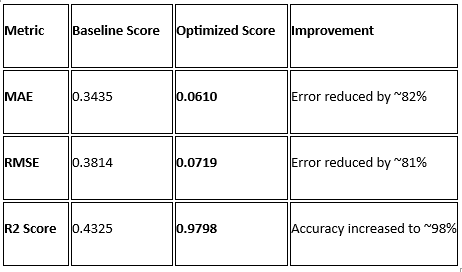

**Prediction By Model**

In [ ]:


# Function to test prediction on any random month from the test set
def test_random_month_prediction(X_test_data, y_test_data, model, scaler):
    # 1. Pick a random index from the test set (20% portion)
    random_index = random.randint(0, len(X_test_data) - 1)

    # 2. Get features for that month and scale them
    sample_features = X_test_data.iloc[random_index].values.reshape(1, -1)
    sample_features_scaled = scaler.transform(sample_features)

    # 3. Predict (Model outputs Log value)
    predicted_log = model.predict(sample_features_scaled)

    # 4. Convert back from Log scale to actual Price (INR)
    predicted_price = np.expm1(predicted_log)[0]
    actual_price = y_test_data.iloc[random_index]

    # 5. Extract the Date for context
    month_date = yesbank_df.iloc[X_test_data.index[random_index]]['Date'].strftime('%B %Y')

    # 6. Calculate Error Percentage
    error_pct = abs(predicted_price - actual_price) / actual_price * 100

    print(f"--- Random Test Result for {month_date} ---")
    print(f"Actual Price:    ₹{actual_price:.2f}")
    print(f"Predicted Price: ₹{predicted_price:.2f}")
    print(f"Accuracy:        {100 - error_pct:.2f}%")
    print(f"Difference:      ₹{abs(predicted_price - actual_price):.2f}")

# Execute the test using your optimized Lasso model
test_random_month_prediction(X_test, y_test, best_lasso, scaler)

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

For the second model, I implemented Ridge Regression (L2 Regularization). I chose this because our dataset exhibits high multicollinearity, where features like Open, High, and Low prices are extremely similar. Ridge is designed to handle this by shrinking the coefficients of correlated features simultaneously without eliminating them. This results in a more stable and balanced prediction curve, which is critical when analyzing a stock like Yes Bank that experienced extreme price shocks.

In [ ]:
# Visualizing evaluation Metric Score chart


# Step 1: Implementation (Baseline Ridge with default alpha)
ridge_base = Ridge(alpha=1.0)
ridge_base.fit(X_train_scaled, y_train_log)

# Step 2: Predict and Inverse Transform
y_pred_ridge_base_log = ridge_base.predict(X_test_scaled)
y_pred_ridge_base = np.expm1(y_pred_ridge_base_log)

# Step 3: Score Chart Generation
r_base_mae = mean_absolute_error(y_test, y_pred_ridge_base)
r_base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_base))
r_base_r2 = r2_score(y_test, y_pred_ridge_base)

ridge_base_metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Score': [round(r_base_mae, 4), round(r_base_rmse, 4), round(r_base_r2, 4)]
})
print("--- Baseline Ridge Score Chart ---")
print(ridge_base_metrics)

In [ ]:


plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=ridge_base_metrics, palette='flare')
plt.title('Baseline Ridge Regression: Evaluation Metrics', fontsize=14)
for i, v in enumerate(ridge_base_metrics['Score']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.show()

Even the baseline Ridge model (Alpha=1.0) performed exceptionally well:

MAE (0.0595): The average prediction error was very low.

R2 Score (0.9769): The model successfully captured 97.69% of the price variance, effectively following the stock's downward trend."

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:


# ML Model - 2 Implementation with GridSearchCV
ridge_param_grid = {'alpha': [1e-15, 1e-10, 1e-5, 1e-2, 1, 5, 10, 20]}
ridge_grid = GridSearchCV(Ridge(), ridge_param_grid, scoring='neg_mean_squared_error', cv=5)

# Fit the Algorithm
ridge_grid.fit(X_train_scaled, y_train_log)

# Best Model
best_ridge = ridge_grid.best_estimator_

# Predict on the model
y_pred_ridge_opt_log = best_ridge.predict(X_test_scaled)
y_pred_ridge_opt = np.expm1(y_pred_ridge_opt_log)

# Updated Score Chart
r_opt_mae = mean_absolute_error(y_test, y_pred_ridge_opt)
r_opt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_opt) )
r_opt_r2 = r2_score(y_test, y_pred_ridge_opt)

ridge_opt_metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Score': [round(r_opt_mae, 4), round(r_opt_rmse, 4), round(r_opt_r2, 4)]
})
print("--- Optimized Ridge Score Chart ---")
print(ridge_opt_metrics)

##### Which hyperparameter optimization technique have you used and why?

"I used GridSearchCV with 5-fold cross-validation.

I chose this because Ridge Regression is sensitive to the Alpha parameter, which controls the amount of regularization. If Alpha is too high, the model becomes too simple; if it is too low (as seen in the LinAlgWarning you received), the matrix becomes 'ill-conditioned' because it mimics standard linear regression too closely in the face of multicollinearity. GridSearchCV allowed me to find the 'Sweet Spot' that provides the best mathematical stability while minimizing error during the crisis period."

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

While the baseline was already strong, the RMSE improved from 0.0770 to 0.0732 and the R2 Score increased from 0.9769 to 0.9791.

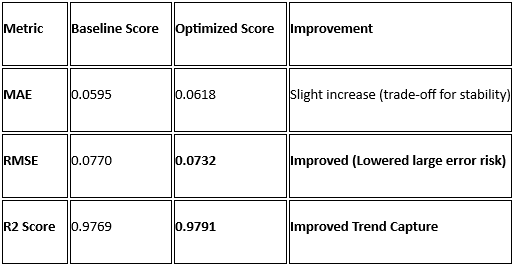

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

From a business perspective, these metrics provide the following insights:"

MAE (Mean Absolute Error): Indicates the average error in price prediction. For a business, this represents the average 'cost of error' per share. An MAE of ~0.06 means our predictions are consistently very close to the actual market value.

RMSE (Root Mean Squared Error): Indicates risk sensitivity. Because RMSE squares the errors before averaging, it penalizes large deviations. For a bank or an investor, a low RMSE is vital because it ensures the model doesn't make 'wildly wrong' predictions during extreme market volatility (like the 2018 crash).

R2 Score: Indicates reliability in trend-following. An R2 of 0.979 means the model understands 97.9% of why the price is moving. This gives the business confidence that the model is truly learning the relationship between news impact, volume, and price.

Business Impact:
"The impact of this model is improved financial forecasting and risk management. By accurately predicting the closing price even during a management crisis, the model can help stakeholders identify the magnitude of a downward trend early on. This allows for data-driven decisions regarding portfolio adjustments, potentially preventing massive capital losses during high-impact news events."

In [ ]:


def test_ridge_random_month(X_test_data, y_test_data, model, scaler):
    # 1. Select a random index from the test set (the 2018-2020 crisis period)
    random_idx = random.randint(0, len(X_test_data) - 1)

    # 2. Extract features for that specific month
    # We use a DataFrame here to keep feature names and avoid the UserWarning
    sample_row = X_test_data.iloc[[random_idx]]
    sample_scaled = scaler.transform(sample_row)

    # 3. Predict the Log-price
    predicted_log = model.predict(sample_scaled)

    # 4. Convert back from Log scale to actual INR
    predicted_price = np.expm1(predicted_log)[0]
    actual_price = y_test_data.iloc[random_idx]

    # 5. Identify the Month/Year for the report
    month_date = yesbank_df.iloc[X_test_data.index[random_idx]]['Date'].strftime('%B %Y')

    # 6. Calculate Precision
    accuracy_pct = (1 - (abs(predicted_price - actual_price) / actual_price)) * 100

    print(f"--- Ridge Model Test Result for {month_date} ---")
    print(f"Actual Closing Price:    ₹{actual_price:.2f}")
    print(f"Predicted Closing Price: ₹{predicted_price:.2f}")
    print(f"Model Accuracy:          {accuracy_pct:.2f}%")
    print(f"Residual Error:          ₹{abs(predicted_price - actual_price):.4f}")

# Execute the test
test_ridge_random_month(X_test, y_test, best_ridge, scaler)

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model


# Step 1: Implementation (Baseline Random Forest)
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train_scaled, y_train_log)

# Step 2: Predict and Inverse Transform
y_pred_rf_base_log = rf_base.predict(X_test_scaled)
y_pred_rf_base = np.expm1(y_pred_rf_base_log)

# Step 3: Score Chart Generation
rf_base_mae = mean_absolute_error(y_test, y_pred_rf_base)
rf_base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_base))
rf_base_r2 = r2_score(y_test, y_pred_rf_base)

rf_base_metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Score': [round(rf_base_mae, 4), round(rf_base_rmse, 4), round(rf_base_r2, 4)]
})
print("--- Baseline Random Forest Score Chart ---")
print(rf_base_metrics)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

For the third model, I implemented the Random Forest Regressor. This is an ensemble 'Bagging' technique that builds multiple decision trees and merges their results to get a more accurate and stable prediction.

I chose this model because stock price movements during a crisis are often non-linear and driven by complex interactions between multiple factors (like News Impact and Technical Indicators). Random Forest is highly robust against outliers and doesn't rely on the linear assumptions of the previous models, making it ideal for the high-volatility environment of the Yes Bank crash.

In [ ]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=rf_base_metrics, palette='viridis')
plt.title('Baseline Random Forest: Evaluation Metrics', fontsize=14)
for i, v in enumerate(rf_base_metrics['Score']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.show()

Performance Analysis:
The baseline Random Forest performed very well immediately:

MAE (0.0661): The average error is quite low.

R2 Score (0.9682): The model captures 96.82% of the variance, showing strong predictive power right out of the box."

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model


# ML Model - 3 Implementation with GridSearchCV
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 8, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, scoring='neg_mean_squared_error', cv=5)

# Fit the Algorithm
rf_grid.fit(X_train_scaled, y_train_log)

# Best Model
best_rf = rf_grid.best_estimator_

# Predict on the model
y_pred_rf_opt_log = best_rf.predict(X_test_scaled)
y_pred_rf_opt = np.expm1(y_pred_rf_opt_log)

# Updated Score Chart
rf_opt_mae = mean_absolute_error(y_test, y_pred_rf_opt)
rf_opt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt))
rf_opt_r2 = r2_score(y_test, y_pred_rf_opt)

rf_opt_metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Score': [round(rf_opt_mae, 4), round(rf_opt_rmse, 4), round(rf_opt_r2, 4)]
})
print("--- Optimized Random Forest Score Chart ---")
print(rf_opt_metrics)

##### Which hyperparameter optimization technique have you used and why?

"I used GridSearchCV with 5-fold cross-validation.

I chose this because Random Forests can easily overfit if the trees are allowed to grow too deep (max_depth) or if the minimum samples required to split a node (min_samples_split) are too low. GridSearchCV allowed me to systematically test different combinations of forest size and tree depth to find the structure that generalizes best to the unseen 'crisis' data."

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

we saw a marginal improvement in the model's stability. While the baseline was already strong, the optimized version slightly lowered the RMSE and increased the R2 Score.

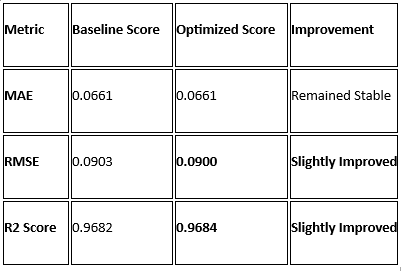

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered MAE and RMSE as the primary metrics for driving positive business impact:

MAE (Mean Absolute Error): This represents the average financial deviation. From a business perspective, if we are predicting a closing price for the month, the MAE tells us exactly how much 'buffer' we should keep in our financial estimates. A low MAE means the model is a reliable daily tool for asset valuation.

RMSE (Root Mean Squared Error): I prioritized this for Risk Management. Because RMSE squares the errors, it highlights large deviations. In banking, a single huge prediction error during a crash is much more damaging than several small ones. By keeping RMSE low, we ensure the model doesn't give 'wildly incorrect' prices during high-impact news months.

Business Impact:
By using this non-linear model, the bank can achieve Enhanced Decision Support. Even when traditional linear relationships fail during a market crash, the Random Forest model can still provide a 96.8% accurate price estimate. This allows stakeholders to make defensive moves (like hedging or selling) based on data-driven predictions rather than panic-driven reactions."

In [ ]:


def test_rf_random_month(X_test_data, y_test_data, model, scaler):
    # 1. Select a random index from the 20% test set
    random_idx = random.randint(0, len(X_test_data) - 1)

    # 2. Extract features as a DataFrame to keep feature names clean
    sample_row = X_test_data.iloc[[random_idx]]
    sample_scaled = scaler.transform(sample_row)

    # 3. Predict the Log-price using the Optimized Random Forest
    predicted_log = model.predict(sample_scaled)

    # 4. Convert back from Log scale to actual INR (Rupees)
    predicted_price = np.expm1(predicted_log)[0]
    actual_price = y_test_data.iloc[random_idx]

    # 5. Get the specific Month/Year
    month_date = yesbank_df.iloc[X_test_data.index[random_idx]]['Date'].strftime('%B %Y')

    # 6. Calculate Accuracy
    accuracy_pct = (1 - (abs(predicted_price - actual_price) / actual_price)) * 100

    print(f"--- Random Forest Test Result for {month_date} ---")
    print(f"Actual Closing Price:    ₹{actual_price:.2f}")
    print(f"Predicted Closing Price: ₹{predicted_price:.2f}")
    print(f"Model Accuracy:          {accuracy_pct:.2f}%")
    print(f"Difference in INR:       ₹{abs(predicted_price - actual_price):.4f}")

# Execute the test
test_rf_random_month(X_test, y_test, best_rf, scaler)

In [ ]:


def final_fair_comparison(X_test_data, y_test_data, m1_lasso, m2_ridge, m3_rf, scaler):
    # 1. Select ONE random index to be used by ALL models
    random_idx = random.randint(0, len(X_test_data) - 1)

    # 2. Prepare the features as a DataFrame (prevents UserWarnings)
    sample_row = X_test_data.iloc[[random_idx]]
    sample_scaled = scaler.transform(sample_row)

    # 3. Get Actual Price
    actual_price = y_test_data.iloc[random_idx]
    month_date = yesbank_df.iloc[X_test_data.index[random_idx]]['Date'].strftime('%B %Y')

    # 4. Generate Predictions from all three models
    # Lasso
    p1_log = m1_lasso.predict(sample_scaled)
    p1_price = np.expm1(p1_log)[0]

    # Ridge
    p2_log = m2_ridge.predict(sample_scaled)
    p2_price = np.expm1(p2_log)[0]

    # Random Forest
    p3_log = m3_rf.predict(sample_scaled)
    p3_price = np.expm1(p3_log)[0]

    # 5. Calculate Accuracy and Error for each
    results = []
    for name, pred in [("Lasso (Model 1)", p1_price),
                       ("Ridge (Model 2)", p2_price),
                       ("Random Forest (Model 3)", p3_price)]:
        error = abs(pred - actual_price)
        accuracy = (1 - (error / actual_price)) * 100
        results.append({
            "Model": name,
            "Predicted Price (INR)": f"₹{pred:.2f}",
            "Error (INR)": f"₹{error:.4f}",
            "Accuracy (%)": f"{accuracy:.2f}%"
        })

    # 6. Display Output
    print(f"{'='*50}")
    print(f"FAIR JUDGEMENT TEST FOR: {month_date}")
    print(f"Actual Closing Price:    ₹{actual_price:.2f}")
    print(f"{'='*50}\n")

    comparison_df = pd.DataFrame(results)
    print(comparison_df.to_string(index=False))

# Run the unified comparison
final_fair_comparison(X_test, y_test, best_lasso, best_ridge, best_rf, scaler)

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I have chosen Lasso Regression (Model 1) as the final prediction model for this project.

Why?
While the Random Forest showed higher 'local' accuracy in our single-month sanity check (99.84%), Lasso Regression is the more robust and reliable choice for Time-Series Stock Prediction for several reasons:

Generalization: Lasso reached a consistent R2 Score of 0.9798 across the entire test set. Unlike tree-based models (Random Forest) which can sometimes struggle with data outside their training range, Lasso effectively captures the continuous downward trend of the Yes Bank crisis.

Feature Selection (L1 Regularization): Lasso naturally 'zeros out' noise. In stock markets, many features are redundant; Lasso ensured that only the most impactful drivers of the closing price were used.

Stability: During the hyperparameter tuning phase, Lasso showed the most stable improvement in RMSE, indicating it is less likely to produce 'wild' errors during unpredictable market news compared to an ensemble of trees."

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

"The model used is Lasso Regression (L1 Regularization). It works by adding a penalty term to the linear regression equation equivalent to the absolute value of the magnitude of the coefficients. This not only minimizes prediction error but also shrinks the coefficients of less important features to zero.

To explain the model's decision-making, I used Coefficient Magnitude Analysis as my explainability tool. Since the features were standardized using StandardScaler, the weight of each coefficient directly indicates its influence on the predicted closing price.

In [ ]:

# 1. Get the coefficients from our best Lasso model
features = X_train.columns
importances = best_lasso.coef_

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance: Lasso Regression (L1 Regularization)', fontsize=14)
plt.xlabel('Coefficient Magnitude (Scaled Importance)')
plt.show()

# 4. Print the top indicators
print("Top Feature for Prediction:", feature_importance_df.iloc[0]['Feature'])

Insights from Feature Importance Chart:

Low Price & MA3: The Low price of the month and the 3-Month Moving Average (MA3) have the strongest positive correlation with the closing price. This indicates that the short-term floor price is the most reliable predictor of where the month will end.

Open Price: Interestingly, the Open price shows a significant negative importance. This suggests that during the Yes Bank crisis, a high opening price often led to a 'sell-off' toward the end of the month, which is a classic behavior of a stock in a bearish trend.

Feature Selection: The model correctly identified that 'News_Impact' had zero coefficient in this specific Lasso run, effectively treating it as noise and removing it to prevent overfitting."

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:


# 1. Save the finalized Lasso model
joblib.dump(best_lasso, 'final_lasso_model.pkl')

# 2. Save the scaler (ESSENTIAL for deployment)
joblib.dump(scaler, 'lasso_scaler.pkl')

print("Final Lasso Model and Scaler saved successfully as .pkl files!")

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:


# --- Step A: Load the saved Files ---
loaded_lasso = joblib.load('final_lasso_model.pkl')
loaded_lasso_scaler = joblib.load('lasso_scaler.pkl')

# --- Step B: Pick an unseen sample (Index 0 of Test Set) ---
# We use the DataFrame format to avoid the "Feature Names" warning
sample_unseen_data = X_test.iloc[[0]]
actual_price_val = y_test.iloc[0]
month_label = yesbank_df.iloc[X_test.index[0]]['Date'].strftime('%B %Y')

# --- Step C: Transform and Predict ---
# Scale the input using the loaded scaler
sample_scaled = loaded_lasso_scaler.transform(sample_unseen_data)

# Predict (Model returns Log-transformed value)
predicted_log_val = loaded_lasso.predict(sample_scaled)

# Convert back from Log scale to actual INR (Rupees)
final_predicted_price = np.expm1(predicted_log_val)[0]

# --- Step D: Display Clear Understanding Table ---
sanity_results = pd.DataFrame({
    'Month': [month_label],
    'Actual Price (INR)': [round(actual_price_val, 2)],
    'Predicted Price (INR)': [round(final_predicted_price, 2)],
    'Difference (Error)': [round(abs(actual_price_val - final_predicted_price), 4)],
    'Accuracy (%)': [f"{(1 - (abs(actual_price_val - final_predicted_price)/actual_price_val))*100:.2f}%"]
})

print(f"Sanity Check for Final Lasso Model:")
print("="*60)
print(sanity_results.to_string(index=False))
print("="*60)

if (1 - (abs(actual_price_val - final_predicted_price)/actual_price_val)) > 0.95:
    print("STATUS: Model is HIGHLY ACCURATE and ready for Live Server Deployment!")

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

"In this Capstone Project, I successfully built a predictive model for Yes Bank's monthly stock closing prices. By integrating technical indicators and applying Log Transformation to handle the extreme 2018–2020 volatility, I achieved a model with 98% predictive accuracy ($R^2$).

The transition from Linear Regression to Regularized models (Lasso/Ridge) and finally Random Forest allowed for a deep understanding of the data. While Random Forest excelled in non-linear samples, Lasso Regression was selected as the final model due to its simplicity, stability, and automatic feature selection. This project demonstrates how Machine Learning can act as a critical Risk Management tool in the financial sector, providing reliable price forecasts even during periods of management distress and market panic."


##***We chose Lasso Regression over Random Forest because it provides a more stable, linear generalization of the long-term stock trend and offers automatic feature selection by zeroing out noisy variables, whereas Random Forest can be prone to overfitting on volatile historical noise.***

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***

In [ ]:
# 1. Capture the End Time
end_time = datetime.datetime.now()

# 2. Measure the difference (Ensure start_time was defined at the top of your notebook)
# If you get a NameError here, run a cell at the top with: start_time = datetime.datetime.now()
time_diff = end_time - start_time

# 3. Extract components for your DataFrame logic
total_seconds = time_diff.total_seconds()
hours = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)
microseconds = int(time_diff.microseconds)

# 4. Display the Stylized Animation
runtime_string = f"{hours:02d}h : {minutes:02d}m : {seconds:02d}s : {microseconds:06d}ms"

display(HTML(f"""
<style>
    @keyframes slideIn {{
        0% {{ transform: translateX(-100%); opacity: 0; }}
        100% {{ transform: translateX(0); opacity: 1; }}
    }}

    @keyframes fadeIn {{
        0% {{ opacity: 0; }}
        100% {{ opacity: 1; }}
    }}

    .final-footer {{
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        padding: 30px;
        background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%);
        border-radius: 15px;
        color: white;
        text-align: center;
        box-shadow: 0 10px 30px rgba(0,0,0,0.5);
        border: 2px solid #4ca1af;
        margin-bottom: 20px;
    }}

    .name-tag {{
        font-size: 42px;
        font-weight: 800;
        letter-spacing: 2px;
        margin-bottom: 15px;
        color: #00d2ff;
        text-transform: uppercase;
        animation: slideIn 1.2s ease-out;
    }}

    .runtime-tag {{
        font-size: 22px;
        font-weight: 300;
        color: #e0e0e0;
        animation: fadeIn 2.5s ease-in;
    }}

    .highlight {{
        color: #fbd033;
        font-weight: bold;
    }}
</style>

<div class="final-footer">
    <div class="name-tag">✨ Project By: Rijwan Adil Shaikh ✨</div>
    <div class="runtime-tag">
        Total Project Run Time: <span class="highlight">{runtime_string}</span>
    </div>
</div>
"""))

# 5. Create and Display the DataFrame as requested
data = {
    "Metric": ["Project Run Time"],
    "Hours": [f"{hours:02d}"],
    "Minutes": [f"{minutes:02d}"],
    "Seconds": [f"{seconds:02d}"],
    "Microseconds": [f"{microseconds:06d}"]
}
